In [28]:
import os
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from problems.base import load_instance

data = []

datasets = ['a', 'b', 'x']

for dataset in datasets:

    folder = f"../datasets/{dataset}"

    for filename in sorted(os.listdir(folder)):
        input = load_instance(f"{folder}/{filename}")

        avg_items_per_order = sum(len(o) for o in input.orders) / len(input.orders)

        wave_size_by_avg_items_per_order = (input.ub - input.lb) / avg_items_per_order

        data.append({
            'dataset': dataset,
            'filename': filename,
            'nOrders': input.nOrders,
            'nItems': input.nItems,
            'nAisles': input.nAisles,
            'avg_items_per_order': avg_items_per_order,
            'lb': input.lb,
            'ub': input.ub,
            'wave_size_by_avg_items_per_order': wave_size_by_avg_items_per_order
        })

df = pd.DataFrame(data)

df.to_csv('instance_characteristics.csv', index=False)

df = df.rename(columns={
    'dataset': 'Dataset',
    'filename': 'Instance',
    'nOrders': 'Orders',
    'nItems': 'Items',
    'nAisles': 'Aisles',
    'avg_items_per_order': 'Avg Items/Order',
    'lb': 'Lower Bound',
    'ub': 'Upper Bound',
    'wave_size_by_avg_items_per_order': 'Wave Size by Avg Items/Order'
})

df.to_csv('instance_characteristics.csv', index=False)

,Dataset,Mean Orders,Mean Items,Mean Aisles
0,a,3054.200000,3179.250000,204.450000
1,b,14824.400000,13527.400000,320.800000
2,x,23835.866667,20622.266667,333.466667


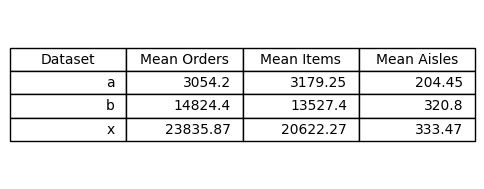

LaTeX (celula 2):
\begin{table}
\caption{Resumo medio por dataset (Orders, Items, Aisles)}
\label{tab:instance_summary_dataset}
\begin{tabular}{lrrr}
\toprule
Dataset & Mean Orders & Mean Items & Mean Aisles \\
\midrule
a & 3054.20 & 3179.25 & 204.45 \\
b & 14824.40 & 13527.40 & 320.80 \\
x & 23835.87 & 20622.27 & 333.47 \\
\bottomrule
\end{tabular}
\end{table}

Arquivo salvo: table6_cell2_summary.tex


In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

if "df" not in globals():
    csv_path = Path("instance_characteristics.csv")
    if not csv_path.exists():
        csv_path = Path("notebooks") / "instance_characteristics.csv"
    df = pd.read_csv(csv_path)

summary = (
    df.groupby("Dataset", as_index=False)[["Orders", "Items", "Aisles"]]
    .mean()
    .rename(
        columns={
            "Orders": "Mean Orders",
            "Items": "Mean Items",
            "Aisles": "Mean Aisles",
        }
    )
)

display(summary)

fig, ax = plt.subplots(figsize=(6, 1 + 0.4 * len(summary)))
ax.axis("off")

table = ax.table(
    cellText=summary.round(2).values,
    colLabels=summary.columns,
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

plt.show()

summary_latex = summary.round(2).to_latex(
    index=False,
    caption="Resumo medio por dataset (Orders, Items, Aisles)",
    label="tab:instance_summary_dataset",
    float_format="%.2f",
)

Path("table6_cell2_summary.tex").write_text(summary_latex, encoding="utf-8")
print("LaTeX (celula 2):")
print(summary_latex)
print("Arquivo salvo: table6_cell2_summary.tex")

In [30]:
from pathlib import Path

import numpy as np
import pandas as pd

if "df" not in globals():
    csv_path = Path("instance_characteristics.csv")
    if not csv_path.exists():
        csv_path = Path("notebooks") / "instance_characteristics.csv"
    df = pd.read_csv(csv_path)

# Base por instância (sem agregação por dataset)
table6 = df.copy().rename(
    columns={
        "dataset": "Dataset",
        "filename": "Instance",
        "nOrders": "Orders",
        "nItems": "Items",
        "nAisles": "Aisles",
        "lb": "Lower Bound",
        "ub": "Upper Bound",
        "avg_items_per_order": "Avg Items/Order",
    }
)

table6["Window Amplitude"] = table6["Upper Bound"] - table6["Lower Bound"]
table6["Restriction Ratio (LB/UB)"] = np.where(
    table6["Upper Bound"] > 0,
    table6["Lower Bound"] / table6["Upper Bound"],
    np.nan,
)
table6["Items/Orders Ratio"] = np.where(
    table6["Orders"] > 0,
    table6["Items"] / table6["Orders"],
    np.nan,
)
table6["Orders/Aisles Ratio"] = np.where(
    table6["Aisles"] > 0,
    table6["Orders"] / table6["Aisles"],
    np.nan,
)

# Esparsidade pedido-item por instância: pares (o, i) com u_oi > 0 / (nOrders * nItems)
# Como Avg Items/Order = media de itens distintos por pedido, temos esparsidade = (Avg Items/Order) / Items
table6["Order-Item Sparsity"] = np.where(
    table6["Items"] > 0,
    table6["Avg Items/Order"] / table6["Items"],
    np.nan,
)

structure_cols = [
    "Dataset",
    "Instance",
    "Orders",
    "Items",
    "Aisles",
    "Items/Orders Ratio",
    "Orders/Aisles Ratio",
    "Order-Item Sparsity",
]
constraint_cols = [
    "Dataset",
    "Instance",
    "Lower Bound",
    "Upper Bound",
    "Window Amplitude",
    "Restriction Ratio (LB/UB)",
]

table6_structure = table6[structure_cols].sort_values(["Dataset", "Instance"]).reset_index(drop=True)
table6_constraints = table6[constraint_cols].sort_values(["Dataset", "Instance"]).reset_index(drop=True)

print("Tabela 6A - Dimensoes Estruturais (por instancia)")
display(table6_structure.round(4))

print("Tabela 6B - Parametros de Restricao (por instancia)")
display(table6_constraints.round(4))

table6_structure_latex = table6_structure.round(4).to_latex(
    index=False,
    caption="Tabela 6A - Dimensoes estruturais por instancia",
    label="tab:tabela6a_estrutural",
    float_format="%.4f",
)
table6_constraints_latex = table6_constraints.round(4).to_latex(
    index=False,
    caption="Tabela 6B - Parametros de restricao por instancia",
    label="tab:tabela6b_restricao",
    float_format="%.4f",
)

Path("table6a_structure.tex").write_text(table6_structure_latex, encoding="utf-8")
Path("table6b_constraints.tex").write_text(table6_constraints_latex, encoding="utf-8")

print("LaTeX (celula 3 - Tabela 6A):")
print(table6_structure_latex)
print("LaTeX (celula 3 - Tabela 6B):")
print(table6_constraints_latex)
print("Arquivos salvos: table6a_structure.tex e table6b_constraints.tex")

Tabela 6A - Dimensoes Estruturais (por instancia)


,Dataset,Instance,Orders,Items,Aisles,Items/Orders Ratio,Orders/Aisles Ratio,Order-Item Sparsity
0,a,instance_0001.txt,61,155,116,2.5410,0.5259,0.0168
1,a,instance_0002.txt,7,7,33,1.0000,0.2121,0.1429
2,a,instance_0003.txt,82,246,124,3.0000,0.6613,0.0123
3,a,instance_0004.txt,16,59,91,3.6875,0.1758,0.0625
4,a,instance_0005.txt,2625,6407,161,2.4408,16.3043,0.0005
5,a,instance_0006.txt,10341,7089,184,0.6855,56.2011,0.0001
6,a,instance_0007.txt,8320,5747,180,0.6907,46.2222,0.0002
7,a,instance_0008.txt,2185,5831,168,2.6686,13.0060,0.0006
8,a,instance_0009.txt,70,222,304,3.1714,0.2303,0.0149
9,a,instance_0010.txt,1602,3689,383,2.3027,4.1828,0.0007


Tabela 6B - Parametros de Restricao (por instancia)


,Dataset,Instance,Lower Bound,Upper Bound,Window Amplitude,Restriction Ratio (LB/UB)
0,a,instance_0001.txt,30,68,38,0.4412
1,a,instance_0002.txt,0,2,2,0.0000
2,a,instance_0003.txt,33,106,73,0.3113
3,a,instance_0004.txt,4,40,36,0.1000
4,a,instance_0005.txt,1322,4395,3073,0.3008
5,a,instance_0006.txt,452,3892,3440,0.1161
6,a,instance_0007.txt,1306,3847,2541,0.3395
7,a,instance_0008.txt,1304,2840,1536,0.4592
8,a,instance_0009.txt,52,153,101,0.3399
9,a,instance_0010.txt,416,1746,1330,0.2383


LaTeX (celula 3 - Tabela 6A):
\begin{table}
\caption{Tabela 6A - Dimensoes estruturais por instancia}
\label{tab:tabela6a_estrutural}
\begin{tabular}{llrrrrrr}
\toprule
Dataset & Instance & Orders & Items & Aisles & Items/Orders Ratio & Orders/Aisles Ratio & Order-Item Sparsity \\
\midrule
a & instance_0001.txt & 61 & 155 & 116 & 2.5410 & 0.5259 & 0.0168 \\
a & instance_0002.txt & 7 & 7 & 33 & 1.0000 & 0.2121 & 0.1429 \\
a & instance_0003.txt & 82 & 246 & 124 & 3.0000 & 0.6613 & 0.0123 \\
a & instance_0004.txt & 16 & 59 & 91 & 3.6875 & 0.1758 & 0.0625 \\
a & instance_0005.txt & 2625 & 6407 & 161 & 2.4408 & 16.3043 & 0.0005 \\
a & instance_0006.txt & 10341 & 7089 & 184 & 0.6855 & 56.2011 & 0.0001 \\
a & instance_0007.txt & 8320 & 5747 & 180 & 0.6907 & 46.2222 & 0.0002 \\
a & instance_0008.txt & 2185 & 5831 & 168 & 2.6686 & 13.0060 & 0.0006 \\
a & instance_0009.txt & 70 & 222 & 304 & 3.1714 & 0.2303 & 0.0149 \\
a & instance_0010.txt & 1602 & 3689 & 383 & 2.3027 & 4.1828 & 0.0007 \\
a & i

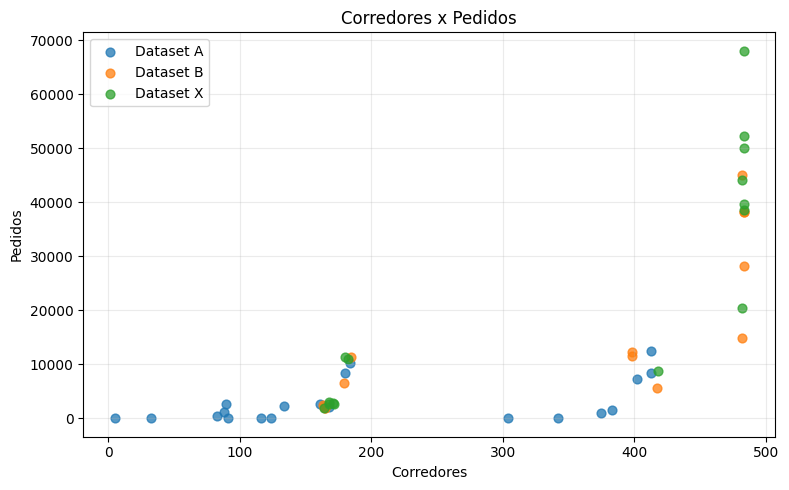

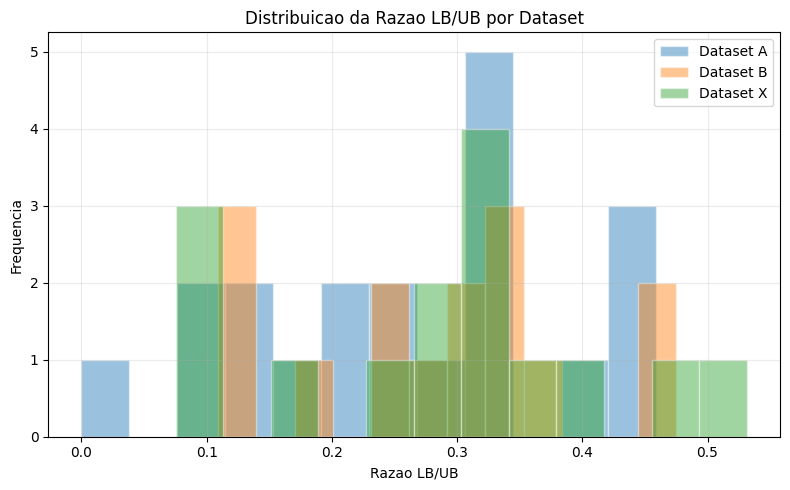

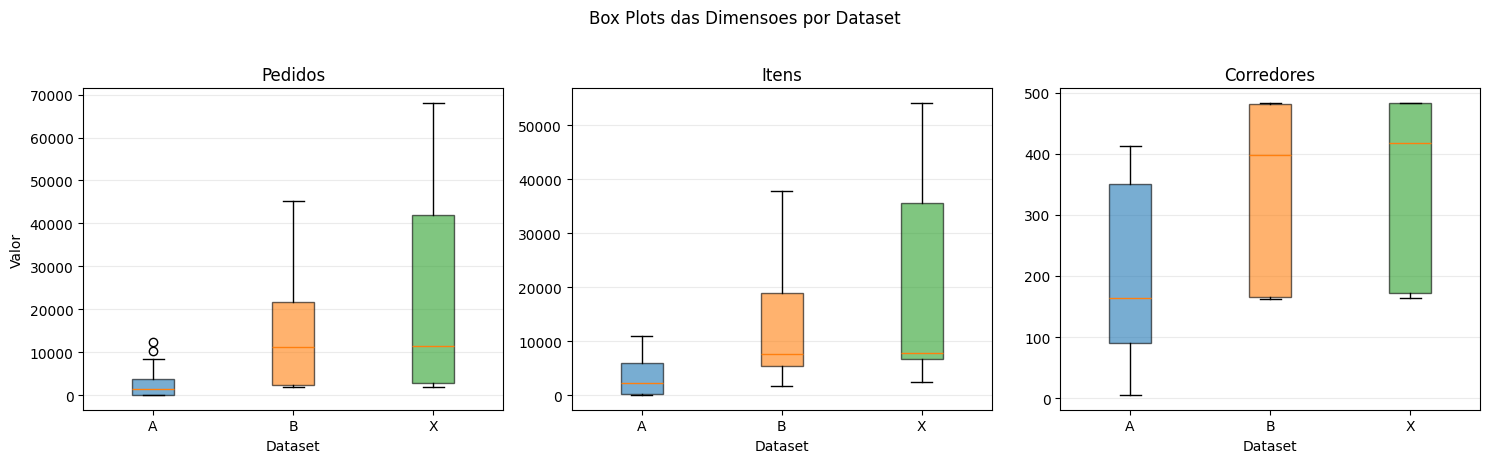

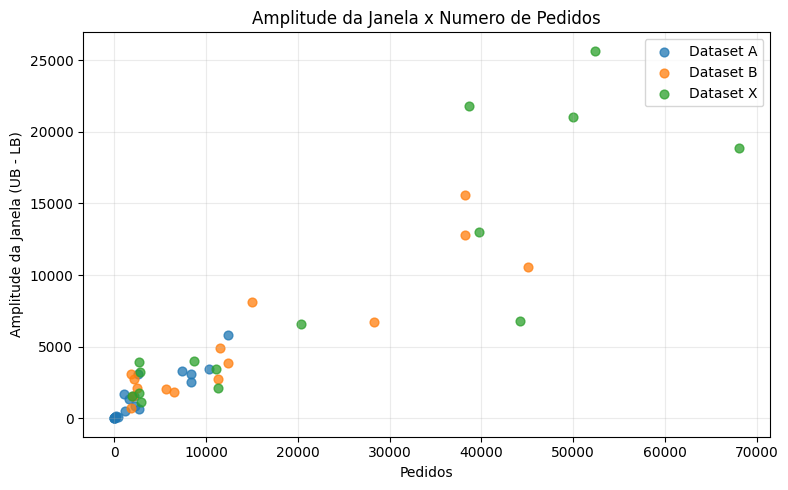

In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "df" not in globals():
    csv_path = Path("instance_characteristics.csv")
    if not csv_path.exists():
        csv_path = Path("notebooks") / "instance_characteristics.csv"
    df = pd.read_csv(csv_path)

plot_df = df.copy().rename(
    columns={
        "dataset": "Dataset",
        "filename": "Instance",
        "nOrders": "Orders",
        "nItems": "Items",
        "nAisles": "Aisles",
        "lb": "Lower Bound",
        "ub": "Upper Bound",
    }
)

plot_df["LB/UB Ratio"] = np.where(
    plot_df["Upper Bound"] > 0,
    plot_df["Lower Bound"] / plot_df["Upper Bound"],
    np.nan,
)
plot_df["Window Amplitude"] = plot_df["Upper Bound"] - plot_df["Lower Bound"]

datasets_order = sorted(plot_df["Dataset"].dropna().unique())
color_map = {
    ds: color for ds, color in zip(datasets_order, ["#1f77b4", "#ff7f0e", "#2ca02c"])
}

# Grafico adicional 1 - Corredores x Pedidos (scatter por dataset)
fig, ax = plt.subplots(figsize=(8, 5))
for ds in datasets_order:
    sub = plot_df[plot_df["Dataset"] == ds]
    ax.scatter(
        sub["Aisles"],
        sub["Orders"],
        s=40,
        alpha=0.75,
        label=f"Dataset {ds.upper()}",
        color=color_map[ds],
    )
ax.set_title("Corredores x Pedidos")
ax.set_xlabel("Corredores")
ax.set_ylabel("Pedidos")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Grafico adicional 2 - Distribuicao da razao LB/UB (histograma por dataset)
fig, ax = plt.subplots(figsize=(8, 5))
for ds in datasets_order:
    sub = plot_df[plot_df["Dataset"] == ds]["LB/UB Ratio"].dropna()
    ax.hist(
        sub,
        bins=12,
        alpha=0.45,
        label=f"Dataset {ds.upper()}",
        color=color_map[ds],
        edgecolor="white",
    )
ax.set_title("Distribuicao da Razao LB/UB por Dataset")
ax.set_xlabel("Razao LB/UB")
ax.set_ylabel("Frequencia")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Grafico adicional 3 - Box plots das dimensoes por dataset (3 paineis)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=False)
metrics = ["Orders", "Items", "Aisles"]
titles = ["Pedidos", "Itens", "Corredores"]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    data_by_dataset = [
        plot_df.loc[plot_df["Dataset"] == ds, metric].dropna().values
        for ds in datasets_order
    ]
    bp = axes[i].boxplot(
        data_by_dataset,
        tick_labels=[ds.upper() for ds in datasets_order],
        patch_artist=True,
        showfliers=True,
    )
    for j, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(color_map[datasets_order[j]])
        patch.set_alpha(0.6)
    axes[i].set_title(title)
    axes[i].set_xlabel("Dataset")
    axes[i].grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Valor")
fig.suptitle("Box Plots das Dimensoes por Dataset", y=1.02)
plt.tight_layout()
plt.show()

# Grafico adicional 4 - Amplitude da janela x numero de pedidos
fig, ax = plt.subplots(figsize=(8, 5))
for ds in datasets_order:
    sub = plot_df[plot_df["Dataset"] == ds]
    ax.scatter(
        sub["Orders"],
        sub["Window Amplitude"],
        s=40,
        alpha=0.75,
        label=f"Dataset {ds.upper()}",
        color=color_map[ds],
    )
ax.set_title("Amplitude da Janela x Numero de Pedidos")
ax.set_xlabel("Pedidos")
ax.set_ylabel("Amplitude da Janela (UB - LB)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()